In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [42]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [43]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [44]:
df.dropna(inplace=True)

In [45]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

How do sales change over time?

In [47]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [48]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [49]:
daily_sales = df.groupby('Order Date')['Sales'].sum()

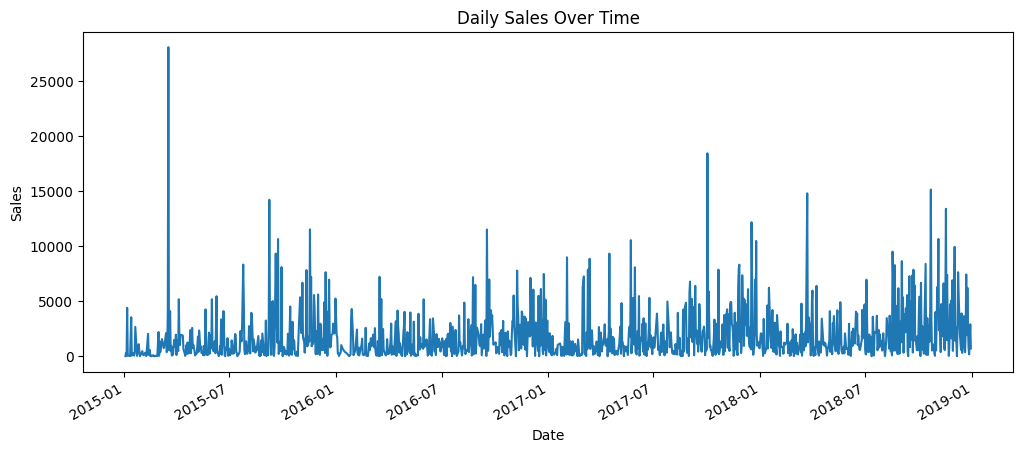

In [50]:
daily_sales.plot(figsize=(12,5))

plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

Which Category generates most Revenue?

In [51]:
category_sales = df.groupby('Category')['Sales'].sum()

Text(0.5, 1.0, 'Sales by Category')

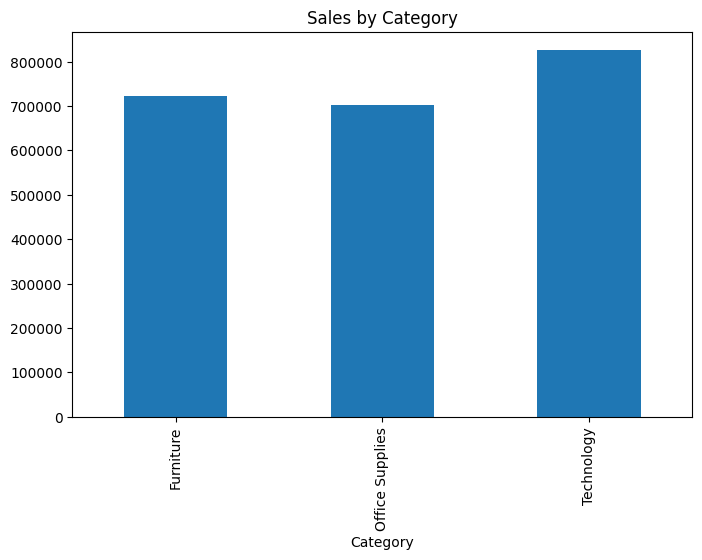

In [52]:
category_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Category')

In [53]:
category_data = pd.DataFrame(df['Category'])

In [54]:
print(category_data['Category'].unique)

<bound method Series.unique of 0             Furniture
1             Furniture
2       Office Supplies
3             Furniture
4       Office Supplies
             ...       
9795    Office Supplies
9796    Office Supplies
9797         Technology
9798         Technology
9799         Technology
Name: Category, Length: 9789, dtype: object>


Question 3. Which sub category sell most?

In [55]:
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values()

Text(0.5, 1.0, 'Sales by Sub-Category')

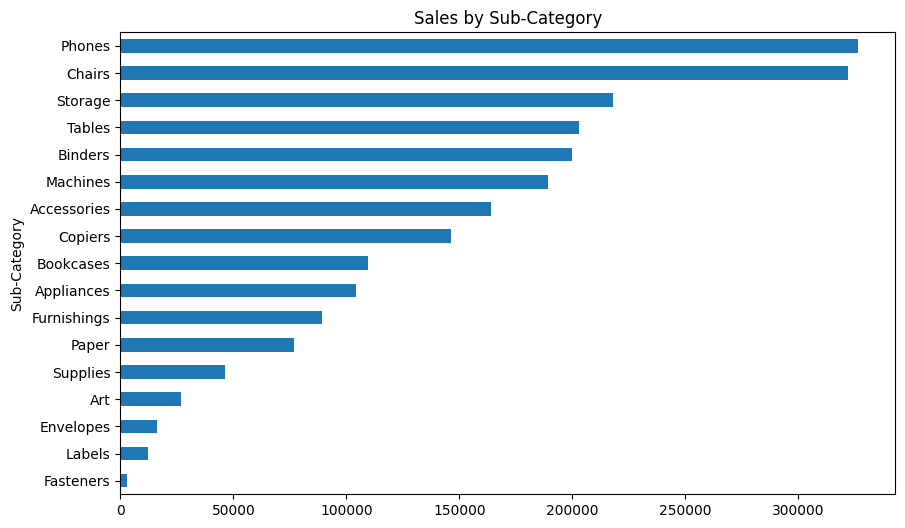

In [56]:
sub_category_sales.plot(kind='barh', figsize=(10,6))
plt.title('Sales by Sub-Category')

Question 4. Which Region generates highest sales?

In [57]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

Text(0.5, 1.0, 'Sales by Region')

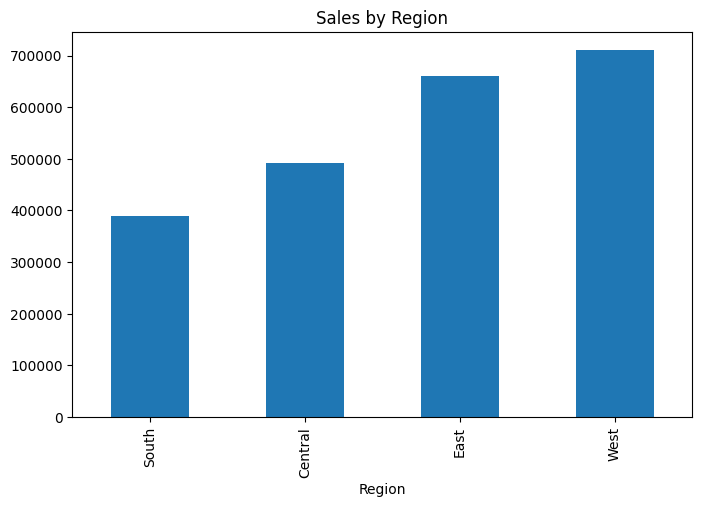

In [58]:
region_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Region')

Top 10 States by Sales

In [59]:
state_sales = df.groupby('State')['Sales'].sum().nlargest(10)

Text(0.5, 1.0, 'Top 10 States by Sales')

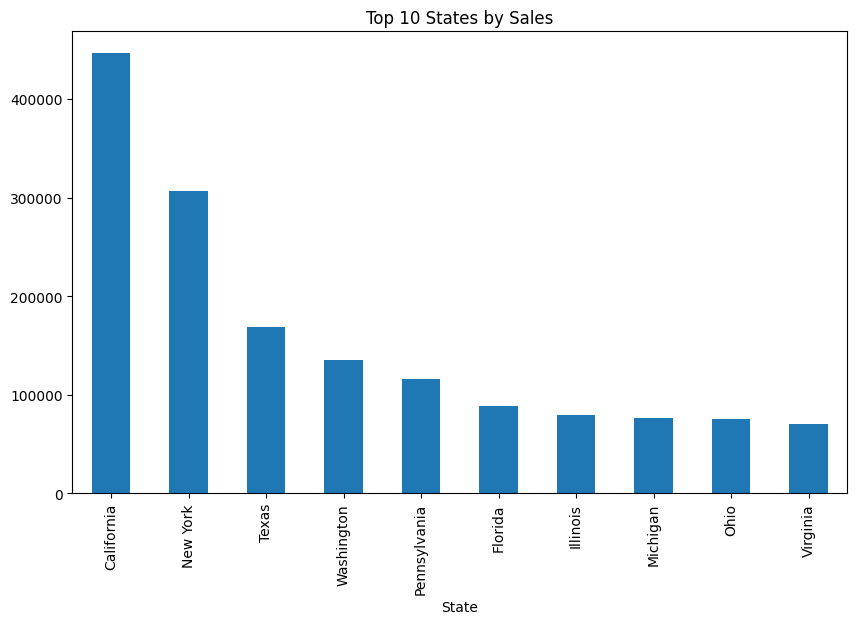

In [60]:
state_sales.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 States by Sales')

Which segment spends the most?

In [61]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values()

Text(0.5, 1.0, 'Sales by Segment')

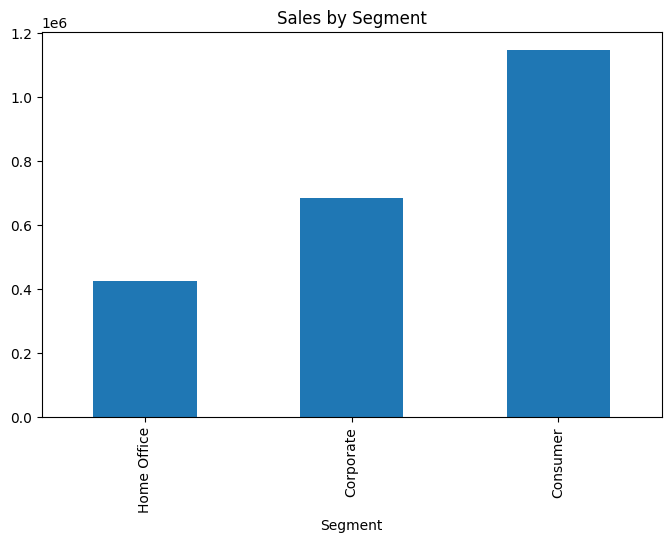

In [62]:
segment_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Segment')

Which shipping mode is most used?

In [63]:
shipping = df['Ship Mode'].value_counts()

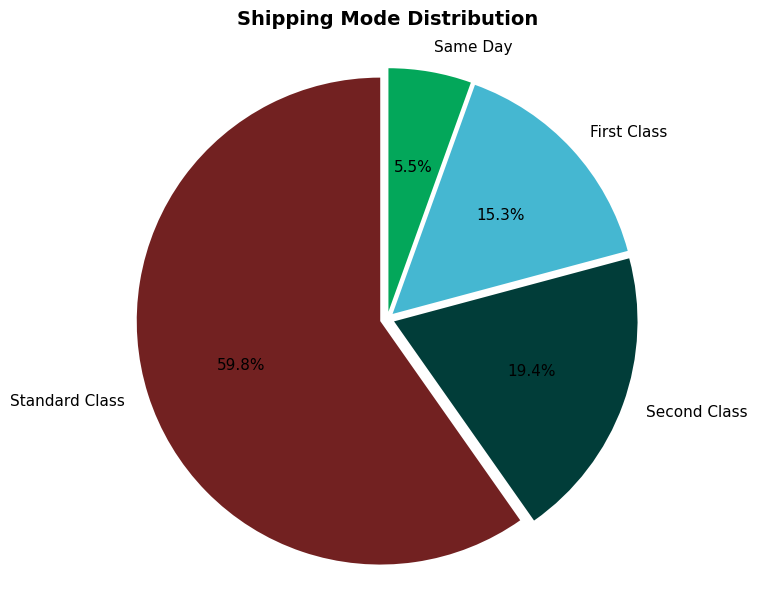

In [64]:
plt.figure(figsize=(8, 6))
colors = ["#722121", "#013D39", '#45B7D1', "#03A75A"]

plt.pie(
    shipping.values,
    labels=shipping.index,
    autopct='%1.1f%%',
    colors=colors[:len(shipping)],
    startangle=90,
    explode=[0.03] * len(shipping),
    
    textprops={'fontsize': 11}
)

plt.title('Shipping Mode Distribution', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [65]:
df['Month'] = df['Order Date'].dt.month_name()

In [66]:
df['Month'].head()

0    November
1    November
2        June
3     October
4     October
Name: Month, dtype: object

In [67]:
month_sales = df.groupby('Month')['Sales'].sum()

Text(0.5, 1.0, 'Monthly Sales Over Time')

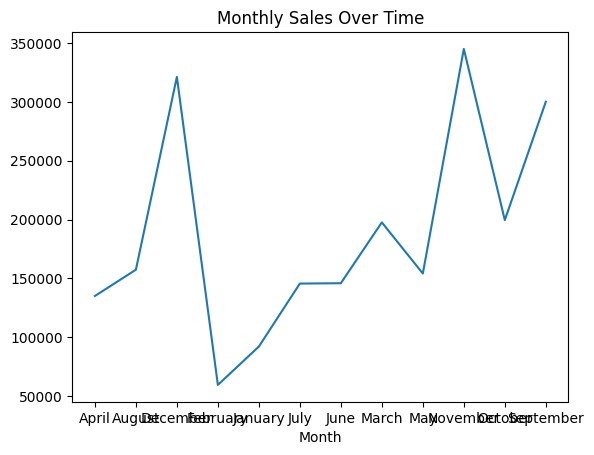

In [68]:
sns.lineplot(x=month_sales.index, y=month_sales.values)
plt.title('Monthly Sales Over Time')